In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install -q -U transformers datasets evaluate accelerate scikit-learn sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.2/11.2 MB 125.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 120.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 17.7 MB/s eta 0:00:00


In [ ]:
import transformers
import datasets
import torch
import sklearn

print("Transformers :", transformers.__version__)
print("Datasets     :", datasets.__version__)
print("PyTorch      :", torch.__version__)
print("ScikitLearn  :", sklearn.__version__)

Transformers : 5.12.1
Datasets     : 5.0.0
PyTorch      : 2.11.0+cu128
ScikitLearn  : 1.9.0


In [ ]:
import torch

print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("❌ No GPU detected")

CUDA Available: True
GPU: Tesla T4


In [ ]:
import transformers

print(transformers.__version__)
print(transformers.__file__)

5.12.1
/usr/local/lib/python3.12/dist-packages/transformers/__init__.py


In [ ]:
!pip show transformers

Name: transformers
Version: 5.12.1
Summary: Transformers: the model-definition framework for state-of-the-art machine learning models in text, vision, audio, and multimodal models, for both inference and training.
Home-page: https://github.com/huggingface/transformers
Author: The Hugging Face team (past and future) with the help of all our contributors (https://github.com/huggingface/transformers/graphs/contributors)
Author-email: transformers@huggingface.co
License: Apache 2.0 License
Location: /usr/local/lib/python3.12/dist-packages
Requires: huggingface-hub, numpy, packaging, pyyaml, regex, safetensors, tokenizers, tqdm, typer
Required-by: peft, sentence-transformers


In [ ]:
# cell 2 starting finally

In [ ]:
import re
import random
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

from datasets import Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
)

In [ ]:
df = pd.read_csv(
    "/content/drive/MyDrive/AI_Neuro_Project/processed_dataset.csv"
)

print(df.head())

print()

print(df.shape)

                                                text                    label
0  I've been having a lot of pain in my neck and ...     cervical spondylosis
1  I have a rash on my face that is getting worse...                 impetigo
2  I have been urinating blood. I sometimes feel ...  urinary tract infection
3  I have been having trouble with my muscles and...                arthritis
4  I have been feeling really sick. My body hurts...                   dengue

(1060, 2)


In [ ]:
print("=" * 50)

print(df.info())

print("=" * 50)

print("Missing Values")
print(df.isnull().sum())

print("=" * 50)

print("Duplicate Rows")
print(df.duplicated().sum())

print("=" * 50)

print("Unique Diseases")
print(df["label"].nunique())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1060 entries, 0 to 1059
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    1060 non-null   object
 1   label   1060 non-null   object
dtypes: object(2)
memory usage: 16.7+ KB
None
Missing Values
text     0
label    0
dtype: int64
Duplicate Rows
0
Unique Diseases
22


In [ ]:
label_counts = df["label"].value_counts()

print(label_counts)

label
impetigo                           50
arthritis                          50
dengue                             50
hypertension                       50
malaria                            50
allergy                            50
psoriasis                          50
chicken pox                        50
diabetes                           50
varicose veins                     50
gastroesophageal reflux disease    49
common cold                        49
cervical spondylosis               49
bronchial asthma                   49
urinary tract infection            48
fungal infection                   48
drug reaction                      48
pneumonia                          47
peptic ulcer disease               47
typhoid                            47
migraine                           42
jaundice                           37
Name: count, dtype: int64


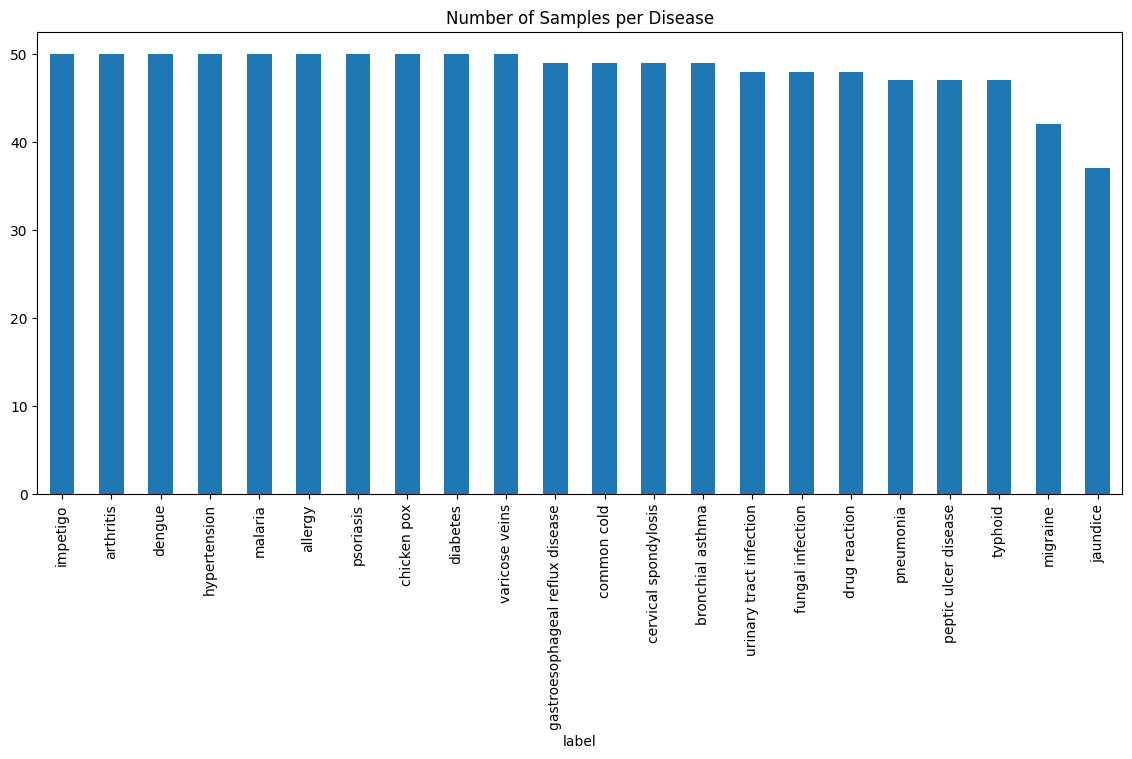

In [ ]:
plt.figure(figsize=(14,6))

label_counts.plot(kind="bar")

plt.xticks(rotation=90)

plt.title("Number of Samples per Disease")

plt.show()

In [ ]:
train_df = pd.read_csv("/content/drive/MyDrive/AI_Neuro_Project/train.csv")
test_df = pd.read_csv("/content/drive/MyDrive/AI_Neuro_Project/test.csv")

print(train_df.shape)
print(test_df.shape)

train_df.head()

(848, 2)
(212, 2)


,text,label
0,"My neck is really stiff, and my muscles are we...",1
1,I've been feeling really sick. I have a high f...,14
2,"I've been having chills, nausea, a high temper...",14
3,I've been really itchy lately and there are th...,9
4,"I have a sour taste in my mouth all the time, ...",10


In [ ]:
import joblib

label_encoder = joblib.load(
    "/content/drive/MyDrive/AI_Neuro_Project/label_encoder.pkl"
)

num_labels = len(label_encoder.classes_)

print(num_labels)
print(label_encoder.classes_)

22
['allergy' 'arthritis' 'bronchial asthma' 'cervical spondylosis'
 'chicken pox' 'common cold' 'dengue' 'diabetes' 'drug reaction'
 'fungal infection' 'gastroesophageal reflux disease' 'hypertension'
 'impetigo' 'jaundice' 'malaria' 'migraine' 'peptic ulcer disease'
 'pneumonia' 'psoriasis' 'typhoid' 'urinary tract infection'
 'varicose veins']


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.7.2 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
from datasets import Dataset

train_dataset = Dataset.from_pandas(train_df)

test_dataset = Dataset.from_pandas(test_df)

In [ ]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        padding=False,
        max_length=128
    )

In [ ]:
tokenized_train = train_dataset.map(
    tokenize,
    batched=True
)

tokenized_test = test_dataset.map(
    tokenize,
    batched=True
)

Map:   0%|          | 0/848 [00:00<?, ? examples/s]

Map:   0%|          | 0/212 [00:00<?, ? examples/s]

In [ ]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

In [ ]:
print(tokenized_train)

Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 848
})


In [ ]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=num_labels
)

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

print(device)

cuda


In [ ]:
import evaluate
import numpy as np

accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):

    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    acc = accuracy.compute(
        predictions=predictions,
        references=labels
    )

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted"
    )

    return {
        "accuracy": acc["accuracy"],
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [ ]:
training_args = TrainingArguments(

    output_dir="./results",

    eval_strategy="epoch",

    save_strategy="epoch",

    load_best_model_at_end=True,

    metric_for_best_model="f1",

    greater_is_better=True,

    learning_rate=2e-5,

    per_device_train_batch_size=16,

    per_device_eval_batch_size=16,

    num_train_epochs=8,

    weight_decay=0.01,

    warmup_ratio=0.1,

    logging_steps=10,

    fp16=torch.cuda.is_available(),

    report_to="none",

    save_total_limit=2,

    seed=42
)

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


In [ ]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,

    processing_class=tokenizer,

    data_collator=data_collator,

    compute_metrics=compute_metrics
)

In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,3.028748,2.949864,0.216981,0.152065,0.216981,0.139801
2,2.486554,2.257334,0.627358,0.540043,0.627358,0.542309
3,1.878687,1.711119,0.764151,0.697693,0.764151,0.701985
4,1.472244,1.329553,0.834906,0.779012,0.834906,0.795753
5,1.157291,1.074866,0.882075,0.907330,0.882075,0.870992
6,0.893532,0.918853,0.900943,0.920851,0.900943,0.889076
7,0.796399,0.827836,0.905660,0.917563,0.905660,0.899235
8,0.741810,0.800644,0.910377,0.920155,0.910377,0.905143


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=424, training_loss=1.6364587387948666, metrics={'train_runtime': 74.3774, 'train_samples_per_second': 91.211, 'train_steps_per_second': 5.701, 'total_flos': 103999150626432.0, 'train_loss': 1.6364587387948666, 'epoch': 8.0})

In [ ]:
results = trainer.evaluate()

print(results)

Training Loss,Validation Loss,Epoch,Accuracy,Precision,Recall,F1
0.741810,0.800644,8,0.910377,0.920155,0.910377,0.905143


{'eval_loss': 0.8006442189216614, 'eval_accuracy': 0.910377358490566, 'eval_precision': 0.9201551854853742, 'eval_recall': 0.910377358490566, 'eval_f1': 0.9051428133731168}


In [ ]:
trainer.save_model(
    "/content/drive/MyDrive/AI_Neuro_Project/trained_model_v2"
)

tokenizer.save_pretrained(
    "/content/drive/MyDrive/AI_Neuro_Project/trained_model_v2"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/AI_Neuro_Project/trained_model_v2/tokenizer_config.json',
 '/content/drive/MyDrive/AI_Neuro_Project/trained_model_v2/tokenizer.json')

In [ ]:
# confusion matrix and a classification report

In [ ]:
predictions = trainer.predict(tokenized_test)

pred_logits = predictions.predictions
pred_labels = np.argmax(pred_logits, axis=1)

true_labels = predictions.label_ids

In [ ]:
from sklearn.metrics import classification_report

print(
    classification_report(
        true_labels,
        pred_labels,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)

                                 precision    recall  f1-score   support

                        allergy       0.90      0.90      0.90        10
                      arthritis       1.00      1.00      1.00        10
               bronchial asthma       1.00      1.00      1.00        10
           cervical spondylosis       1.00      1.00      1.00        10
                    chicken pox       1.00      0.70      0.82        10
                    common cold       0.91      1.00      0.95        10
                         dengue       0.90      0.90      0.90        10
                       diabetes       0.78      0.70      0.74        10
                  drug reaction       0.80      0.40      0.53        10
               fungal infection       1.00      1.00      1.00        10
gastroesophageal reflux disease       0.77      1.00      0.87        10
                   hypertension       1.00      1.00      1.00        10
                       impetigo       1.00      1.

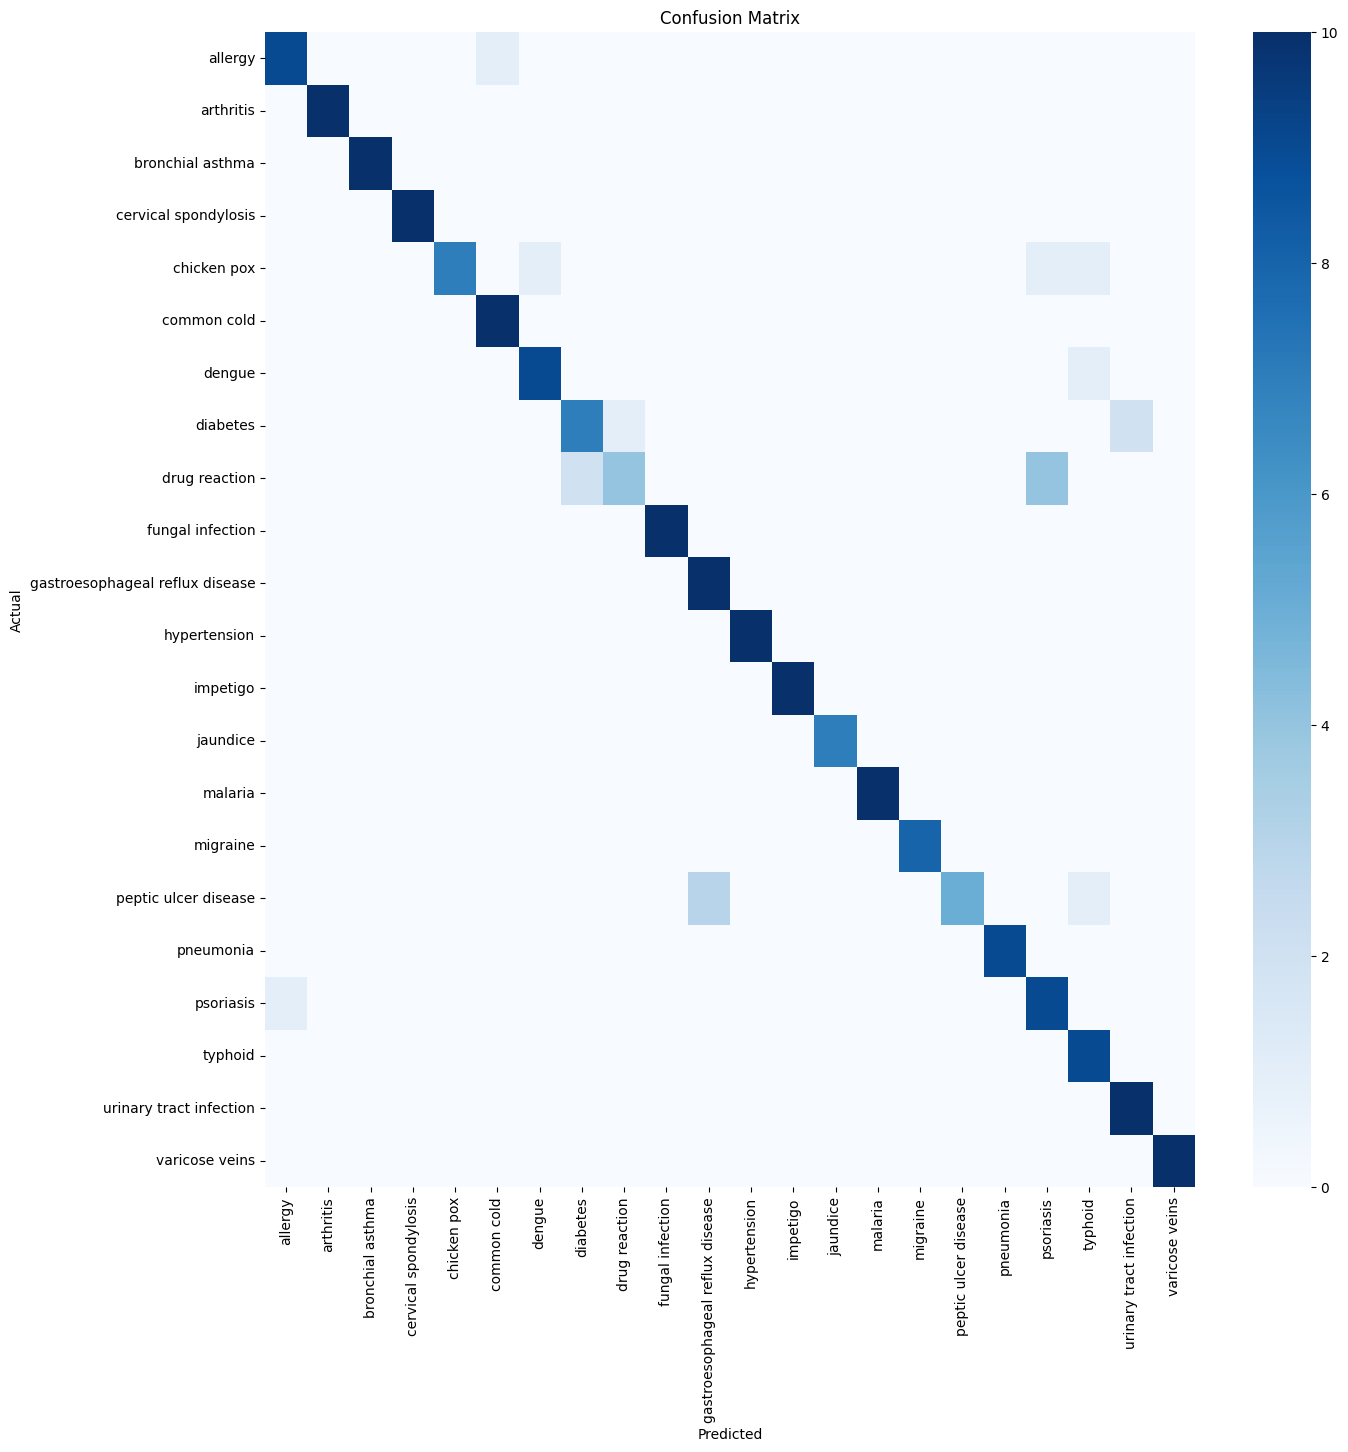

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(true_labels, pred_labels)

plt.figure(figsize=(15,15))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [ ]:
test_texts = test_df["text"].tolist()

wrong_predictions = []

for i in range(len(true_labels)):
    if true_labels[i] != pred_labels[i]:
        wrong_predictions.append({
            "Text": test_texts[i],
            "Actual": label_encoder.inverse_transform([true_labels[i]])[0],
            "Predicted": label_encoder.inverse_transform([pred_labels[i]])[0]
        })

wrong_df = pd.DataFrame(wrong_predictions)

wrong_df.head(20)

,Text,Actual,Predicted
0,I've been vomiting for a few days now and I've...,dengue,typhoid
1,I have rashes on my chest and back and I itch ...,drug reaction,psoriasis
2,"I have trouble breathing, especially when I'm ...",diabetes,urinary tract infection
3,I have difficulty swallowing food and often ge...,peptic ulcer disease,gastroesophageal reflux disease
4,I have a burning feeling in my stomach. It's w...,peptic ulcer disease,gastroesophageal reflux disease
5,"I have a rash on my back and chest, and my ent...",drug reaction,psoriasis
6,"I have red and inflamed skin around my mouth, ...",psoriasis,allergy
7,I have trouble focusing and remembering things...,drug reaction,diabetes
8,"I'm not interested in sex anymore, and it's ha...",drug reaction,diabetes
9,I have a rash on my skin that is causing a lot...,chicken pox,psoriasis


In [ ]:
trainer.save_model(
    "/content/drive/MyDrive/AI_Neuro_Project/trained_model_v2"
)

tokenizer.save_pretrained(
    "/content/drive/MyDrive/AI_Neuro_Project/trained_model_v2"
)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('/content/drive/MyDrive/AI_Neuro_Project/trained_model_v2/tokenizer_config.json',
 '/content/drive/MyDrive/AI_Neuro_Project/trained_model_v2/tokenizer.json')

In [ ]:
# top 3 prediction verison

In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification

model_path = "/content/drive/MyDrive/AI_Neuro_Project/trained_model_v2"

tokenizer = AutoTokenizer.from_pretrained(model_path)

model = AutoModelForSequenceClassification.from_pretrained(model_path)

model.eval()

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSelfAttention(
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)


In [ ]:
import torch
import torch.nn.functional as F

def predict_disease(text):

    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    if torch.cuda.is_available():
        inputs = {k: v.to("cuda") for k, v in inputs.items()}
        model.to("cuda")

    with torch.no_grad():
        outputs = model(**inputs)

    probabilities = F.softmax(outputs.logits, dim=1)

    top_probs, top_indices = torch.topk(probabilities, k=3)

    top_probs = top_probs.cpu().numpy()[0]
    top_indices = top_indices.cpu().numpy()[0]

    print("=" * 60)

    print("Predictions:\n")

    for i in range(3):
        disease = label_encoder.inverse_transform([top_indices[i]])[0]

        confidence = top_probs[i] * 100

        print(f"{i+1}. {disease:30} {confidence:.2f}%")

    print("=" * 60)

In [ ]:
predict_disease(
    "I have been experiencing eyesight problems, increased appetite, a sore neck, melancholy, irritability, regular headaches, acid reflux, indigestion, and frequent migraines. These symptoms have been making my regular activities more challenging and causing me a great deal of distress."
)

NameError: name 'predict_disease' is not defined